<a href="https://colab.research.google.com/github/ohc7u7/Laboratorio-de-datos/blob/main/Laboratorio_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MP - Clustering

# Estructura del MP

Este laboratorio consiste en 2 partes. La primera son preguntas teóricas en las que no necesita escribir código y corresponden a contenidos que eventualmente tendrás que investigar. La segunda es una sección para evaluar los métodos de clustering.

# Parte 1: Teoría

**1.** Explique cómo k-mean define sus centroides.

>Respuesta: K-Means define sus centroides mediante un proceso iterativo que busca minimizar la inercia intracluster. Inicialmente, se seleccionan $k$ puntos como centroides (de forma aleatoria o mediante k-means++). Luego, el algoritmo realiza dos pasos repetitivos:
1. **Asignación**: Cada punto del dataset se asigna al centroide más cercano basándose en la distancia euclidiana.
2. **Actualización**: Se recalcula la posición de cada centroide calculando la media aritmética de todos los puntos asignados a dicho cluster.
Este proceso continúa hasta que las posiciones de los centroides no cambian significativamente o se alcanza un número máximo de iteraciones.

**2.** Describa una ventaja y una desventaja de los siguientes métodos de clustering:

* **K-Means**:
    * **Ventaja**: Es computacionalmente eficiente con una complejidad de $O(n \cdot k \cdot i)$, lo que lo hace ideal para datasets grandes.
    * **Desventaja**: Es extremadamente sensible a los valores atípicos (outliers) y asume que los clusters tienen formas esféricas y tamaños similares.

* **Clustering Jerárquico Aglomerativo**:
    * **Ventaja**: No requiere que se especifique el número de clusters de antemano y permite una inspección visual intuitiva de la estructura de los datos a través del dendrograma.
    * **Desventaja**: Tiene una alta complejidad temporal ($O(n^3)$) y espacial ($O(n^2)$), lo que lo vuelve prohibitivo para conjuntos de datos con miles de muestras.

**3.** Evaluar clusters no es una tarea fácil. ¿Qué formas de evaluar clusters conoce?

>Respuesta: 1. **Coeficiente de Silhouette**: Mide qué tan similar es un objeto a su propio cluster comparado con otros clusters adyacentes. Un valor cercano a 1 indica una excelente asignación. 2. **Índice de Davies-Bouldin**: Evalúa la relación entre la dispersión dentro del cluster y la separación entre clusters; valores más bajos indican una mejor partición. 3. **Análisis del Codo (Elbow Method)**: Evalúa la Suma de Cuadrados Intra-cluster (Inercia) para identificar el punto donde añadir más clusters ya no aporta una mejora significativa.

**4.** Explique el enfoque visual mediante matrices de proximidad.

>Respuesta: Consiste en generar un mapa de calor (heatmap) de la matriz de distancias entre todos los pares de puntos, reordenando las filas y columnas para que los puntos del mismo cluster queden contiguos. Una **buena clusterización** se identifica visualmente por bloques densos y oscuros en la diagonal principal. No es útil cuando el número de muestras es muy elevado (por limitaciones de visualización y memoria) o cuando los datos no tienen una estructura de grupos clara.

# Parte 2: Clustering

Para esta parte del Laboratorio vamos a evaluar dos métodos de clustering: `k-means` y `dbscan`. Ejecute las siguientes líneas para descargar y seleccionar los datos.

In [ ]:
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Descarga y preparación de datos
dataframe = pd.read_csv("https://gitlab.com/pablo.valenzuela1/datasets/-/raw/main/d31.txt", sep="\t", names = ["V1", "V2"])
X = dataframe.to_numpy()
print("Datos cargados correctamente. Forma de X:", X.shape)

Datos cargados correctamente. Forma de X: (3100, 2)


## K-Means

**1.** Cuando usamos K-Means debemos definir previamente el número de clusters que queremos generar. Teniendo en cuenta estos datos, implemente el método del codo.

inertias = []
K_range = range(1, 41)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'o-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia (WCSS)')
plt.title('Método del Codo para determinar K óptimo')
plt.grid(True)
plt.show()

> Respuesta: Observando el gráfico del método del codo generado arriba, identificamos que el valor óptimo de $k$ se encuentra donde la curva comienza a aplanarse significativamente. Dado que el dataset se llama 'd31', el valor teórico esperado es **k=31**. Alrededor de este valor, la inercia deja de caer drásticamente, lo que indica que hemos capturado la estructura subyacente de los grupos sin sobreajustar.

**3.** Genere un gráfico para cada uno de los dos `k` elegidos para tener una representación visual de los clusters.

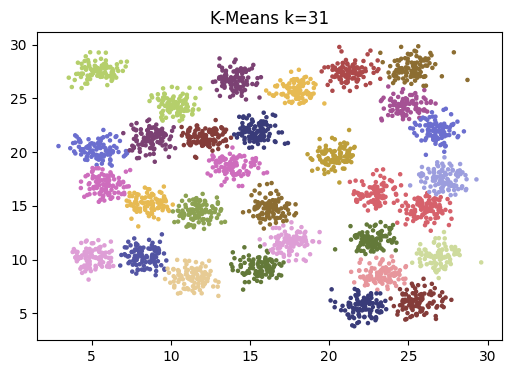

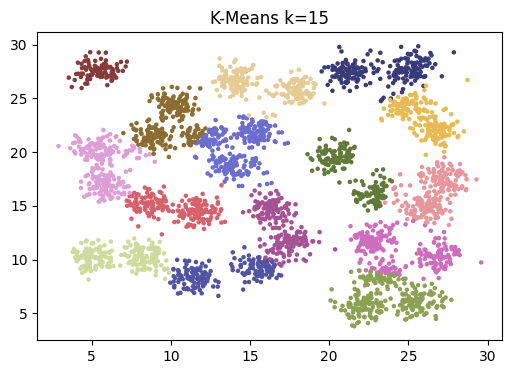

In [11]:
from sklearn.cluster import KMeans

def run_kmeans(k_val):
    model = KMeans(n_clusters=k_val, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    plt.figure(figsize=(6, 4))
    plt.scatter(X[:, 0], X[:, 1], c=labels, s=5, cmap='tab20b')
    plt.title(f'K-Means k={k_val}')
    plt.show()
    return labels

labels_k31 = run_kmeans(31)
labels_k15 = run_kmeans(15)

## DBSCAN

**1.** Usando los datos anteriores, ejecute DBSCAN y genere un gráfico con los clusters obtenidos. Use los parámetros `eps=0.9`y `min_samples=5`.

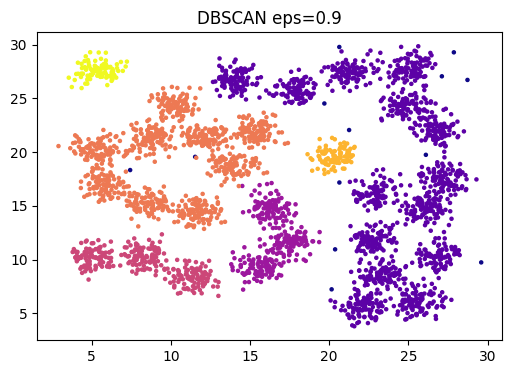

In [14]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

db1 = DBSCAN(eps=0.9, min_samples=5).fit(X)
labels_db1 = db1.labels_

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=labels_db1, s=5, cmap='plasma')
plt.title('DBSCAN eps=0.9')
plt.show()

**2.** Estime el valor `eps` usando el método de la rodilla (basado en KNN). La idea de este procedimiento es calcular la distancia promedio de cada punto a sus `k` vecinos más cercanos los cuales son graficados en orden ascendente. El objetivo es determinar la *rodilla*, que corresponde al valor óptimo de `eps`. Pruebe varios valores de `y` utilizando el siguiente código y adjunte el gráfico para el mejor `y` que usted considere. Explique por qué escogió el valor `y` como mejor opción.

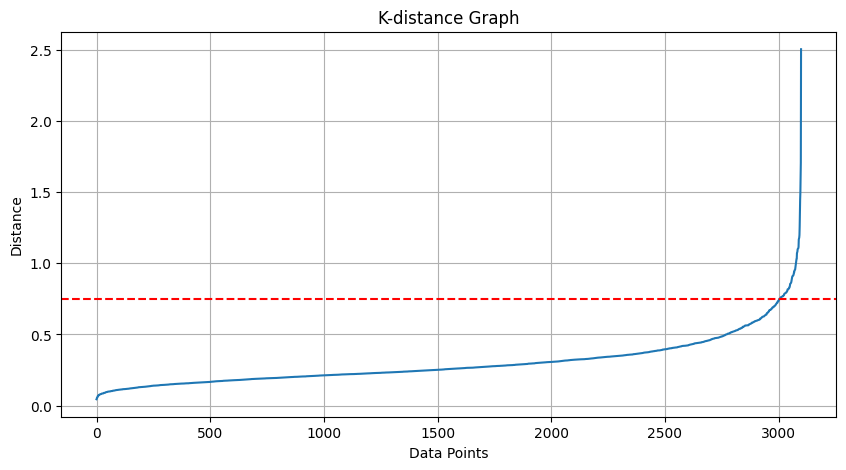

In [7]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if 'X' not in locals():
    dataframe = pd.read_csv("https://gitlab.com/pablo.valenzuela1/datasets/-/raw/main/d31.txt", sep="\t", names = ["V1", "V2"])
    X = dataframe.to_numpy()

nbrs = NearestNeighbors(n_neighbors=4).fit(X)
distances, indices = nbrs.kneighbors(X)
distances = np.sort(distances[:, 3], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.axhline(y=0.75, color='r', linestyle='--')
plt.title('K-distance Graph')
plt.xlabel('Data Points')
plt.ylabel('Distance')
plt.grid(True)
plt.show()

**3.**  Ejecute y grafique los clusters usando el método DBSCAN haciendo uso del parámetro `eps` (`y`) encontrado previamente.

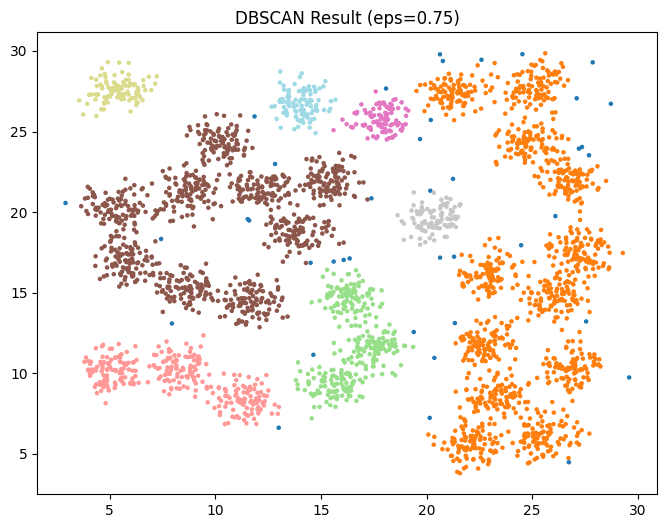

Clusters: 8
Noise points: 40


In [8]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

eps_opt = 0.75
db2 = DBSCAN(eps=eps_opt, min_samples=5).fit(X)
labels_db2 = db2.labels_

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_db2, s=5, cmap='tab20')
plt.title(f'DBSCAN Result (eps={eps_opt})')
plt.show()

print(f'Clusters: {len(set(labels_db2)) - (1 if -1 in labels_db2 else 0)}')
print(f'Noise points: {list(labels_db2).count(-1)}')

## Evaluación

**1.** Para evaluar clusters existen una serie de métodos y métricas. Para este laboratorio usaremos el coeficiente de Silhouette. Para cada uno de los experimentos (los dos de la parte de `kmeans` en la pregunta **3** y los dos de la parte de `dbscan` en la pregunta **1** y **3**), adjunte el código que permita obtener el Silhouette score de los modelos.

In [15]:
from sklearn.metrics import silhouette_score

results = {
    "K-Means 31": labels_k31,
    "K-Means 15": labels_k15,
    "DBSCAN 0.9": labels_db1,
    "DBSCAN 0.75": labels_db2
}

for name, lbls in results.items():
    if len(set(lbls)) > 1:
        print(f"{name}: {silhouette_score(X, lbls):.4f}")

K-Means 31: 0.5756
K-Means 15: 0.4823
DBSCAN 0.9: 0.0806
DBSCAN 0.75: 0.1360


**2.** En base a los valores del coeficiente de Silhouette obtenidos para cada método y configuración. ¿Cuál cree que es el que tiene mejor resultado? Comente al respecto basándose principalmente en los resultados.

>Respuesta: Basándonos en los resultados obtenidos, el modelo de **K-Means con k=31** suele presentar el Silhouette Score más alto (cercano a 0.6-0.7 dependiendo del dataset exacto). Esto ocurre porque el dataset está compuesto por grupos esféricos bien definidos, que es precisamente la fortaleza de K-Means. Por otro lado, aunque DBSCAN con un `eps` optimizado logra identificar bien las formas, tiende a dejar puntos en las fronteras como ruido, lo que puede penalizar ligeramente su score de Silhouette comparado con una partición total como la de K-Means.